In [3]:
import pandas as pd

df = pd.read_csv("dirty_cafe_sales.csv")
print(df.head())


  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


In [6]:
print(df.tail())

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
9995    TXN_7672686    Coffee        2            2.0         4.0   
9996    TXN_9659401       NaN        3            NaN         3.0   
9997    TXN_5255387    Coffee        4            2.0         8.0   
9998    TXN_7695629    Cookie        3            NaN         3.0   
9999    TXN_6170729  Sandwich        3            4.0        12.0   

      Payment Method  Location Transaction Date  
9995             NaN   UNKNOWN       2023-08-30  
9996  Digital Wallet       NaN       2023-06-02  
9997  Digital Wallet       NaN       2023-03-02  
9998  Digital Wallet       NaN       2023-12-02  
9999            Cash  In-store       2023-11-07  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None


In [8]:
print(df.isnull().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [13]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64


In [14]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

In [15]:
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Price Per Unit'].fillna(df['Price Per Unit'].median(), inplace=True)

C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_33248\3091448775.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_33248\3091448775.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [16]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [17]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [18]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Transaction ID       0.00
Item                 3.33
Quantity             0.00
Price Per Unit       0.00
Total Spent          0.00
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64


In [19]:
df['Item'].fillna("Unknown", inplace=True)
df['Payment Method'].fillna("Unknown", inplace=True)
df['Location'].fillna("Unknown", inplace=True)

C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_33248\1372298832.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item'].fillna("Unknown", inplace=True)
C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_33248\1372298832.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [20]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Transaction ID      0.00
Item                0.00
Quantity            0.00
Price Per Unit      0.00
Total Spent         0.00
Payment Method      0.00
Location            0.00
Transaction Date    1.59
dtype: float64


In [21]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [22]:
print(df['Transaction Date'].isnull().sum())

460


In [23]:
df['Transaction Date'].fillna(method='ffill', inplace=True)

C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_33248\3186130383.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transaction Date'].fillna(method='ffill', inplace=True)
C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_33248\3186130383.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Transaction Date'].fillna(method='ffill', inplace=True)


In [30]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [31]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -8.0
Upper Bound: 24.0


In [34]:
outliers = df[df['Total Spent'] > 24]
print("Number of Outliers:", len(outliers))
outliers.head()

Number of Outliers: 240


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
51,TXN_6342161,Salad,5.0,5.0,25.0,ERROR,Takeaway,2023-01-08
52,TXN_8914892,UNKNOWN,5.0,5.0,25.0,Digital Wallet,Unknown,2023-03-15
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-store,2023-06-10
100,TXN_9517146,Unknown,5.0,5.0,25.0,Cash,Takeaway,2023-10-30


In [35]:
print((240 / len(df)) * 100)

2.4


In [36]:
df['Payment Method'] = df['Payment Method'].replace('ERROR', 'Unknown')
df['Item'] = df['Item'].replace('UNKNOWN', 'Unknown')

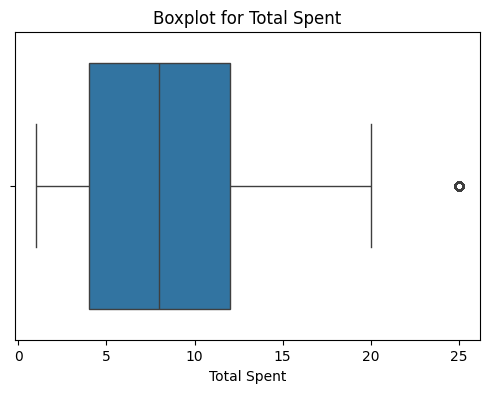

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total Spent'])
plt.title("Boxplot for Total Spent")
plt.show()

In [ ]:
df.to_csv("cafe_sales_cleaned.csv", index=False)

#df.to_csv(r"C:\Users\PRIYANSHU\Desktop\cafe_sales_cleaned.csv", index=False)  optional to save on specific location

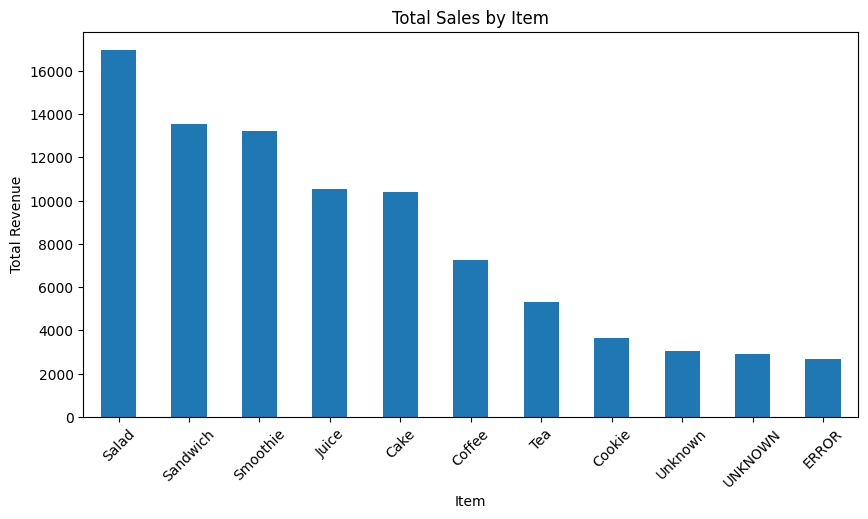

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
top_items = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

top_items.plot(kind='bar')
plt.title("Total Sales by Item")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

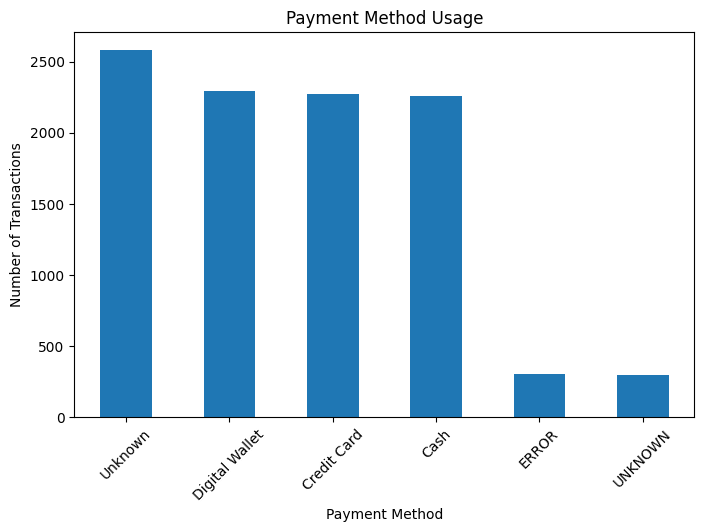

In [25]:
plt.figure(figsize=(8,5))
df["Payment Method"].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

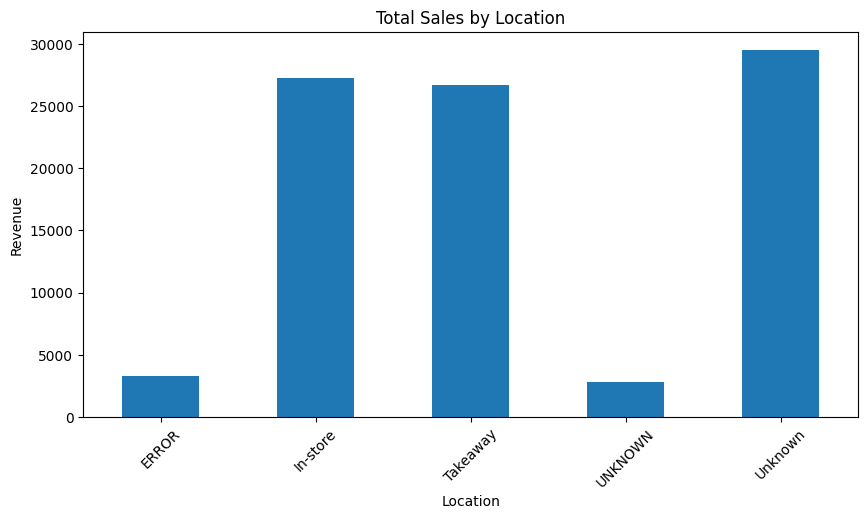

In [26]:
plt.figure(figsize=(10,5))
df.groupby("Location")["Total Spent"].sum().plot(kind='bar')
plt.title("Total Sales by Location")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

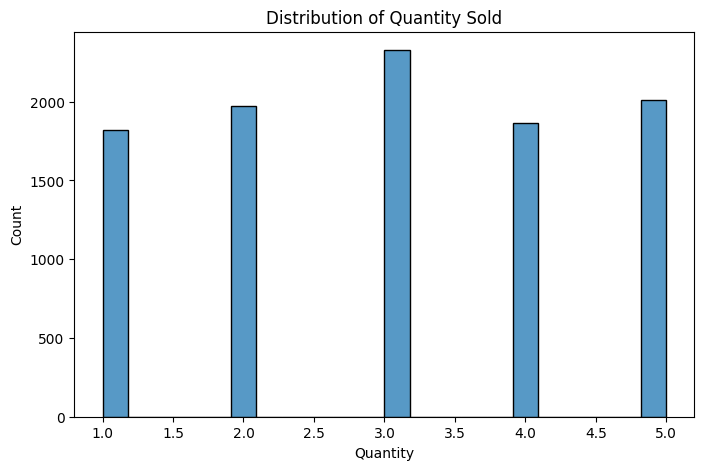

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"])
plt.title("Distribution of Quantity Sold")
plt.show()

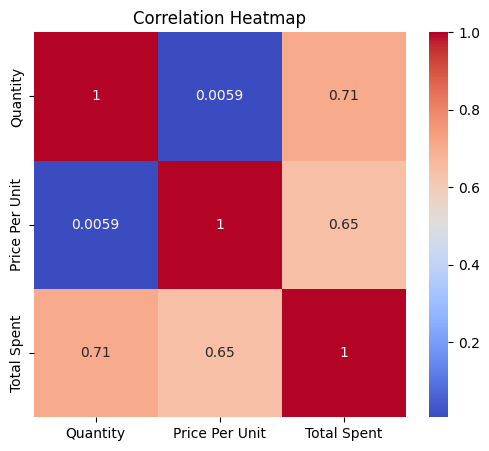

In [29]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()